In [1]:
import os
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from spisea import synthetic, evolution, atmospheres, reddening
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/scratch/wyz5rge/synthetic-hr/cmd_generator')
import interpolator as interpolator

/home/wyz5rge/.local/lib/python3.6/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /scratch/wyz5rge/models/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [17]:
# -----------------------------
# SPISEA / photometry settings
# -----------------------------
AKs = 0
dist = 410
metallicity = 0

evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawHosek18b()

# Match Andersen-style CMD
filt_list = ['jwst,F162M', 'jwst,F182M']
filters = ['m_jwst_F162M', 'm_jwst_F182M']

iso_dir = 'isochrones/'

# -----------------------------
# Simulation paths
# -----------------------------
BASE_HIGH_DENSITY = '/storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0'

SIM_PATHS = {
    '1.0_0.03': os.path.join(BASE_HIGH_DENSITY, 'sfeff003_00') + '/',
    '1.0_1.00': os.path.join(BASE_HIGH_DENSITY, 'sfeff100_00') + '/',
}

# formation times (your values)
T_STAR_BY_EFF = {
    0.03: 6.47,
    1.00: 0.19,
}

# -----------------------------
# Old thesis metric box
# Adjust these if needed for F162M-F182M vs F162M
# -----------------------------
BOX_COLOR_MIN = -0.10
BOX_COLOR_MAX = 0.10
BOX_MAG_MIN = 10.5
BOX_MAG_MAX = 13.0
BOX_COLOR_STEP = 0.05

# New metric mass window
MASS_MIN = 0.10
MASS_MAX = 0.40

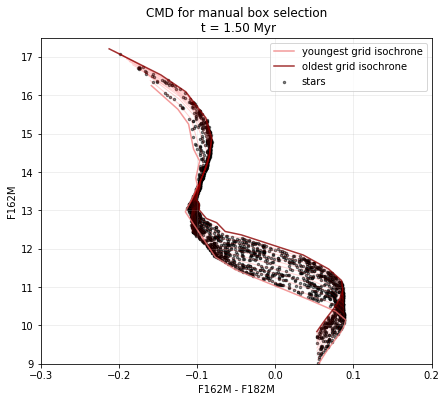

In [18]:
def plot_cmd_for_manual_box_selection(sim_path, snapshot_time_myr, force_single_age_myr=None,
                                      xlim=None, ylim=None, increment_yr=0.1e6):
    """
    Plot one CMD cleanly so you can choose the old-method bounding box by eye.
    """
    out = evaluate_snapshot(sim_path, snapshot_time_myr, force_single_age_myr=force_single_age_myr)
    stars = out['interp']['stars']
    instances = out['interp']['instances']

    plt.figure(figsize=(7, 6))

    # isochrone grid
    for i in range(len(instances)):
        pts = instances[i].points
        color = pts[filters[0]] - pts[filters[1]]
        mag = pts[filters[0]]

        if i == 0:
            plt.plot(color, mag, color='lightcoral', alpha=0.8, lw=1.5, label='youngest grid isochrone')
        elif i == len(instances) - 1:
            plt.plot(color, mag, color='darkred', alpha=0.8, lw=1.5, label='oldest grid isochrone')
        else:
            plt.plot(color, mag, color='red', alpha=0.18, lw=1.0)

    # stars
    xs, ys = [], []
    for star in stars:
        if star is None:
            continue
        cmd = cmd_coords_from_star(star)
        if cmd is None:
            continue
        xs.append(cmd[0])
        ys.append(cmd[1])

    plt.scatter(xs, ys, s=6, c='k', alpha=0.5, label='stars')

    if xlim is not None:
        plt.xlim(*xlim)
    if ylim is not None:
        plt.ylim(*ylim)

    plt.gca().invert_yaxis()
    plt.xlabel('F162M - F182M')
    plt.ylabel('F162M')
    plt.title(f'CMD for manual box selection\n t = {snapshot_time_myr:.2f} Myr')
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()
    
plot_cmd_for_manual_box_selection(
    SIM_PATHS['1.0_0.03'],
    snapshot_time_myr=1.5,
    xlim=(-0.30, 0.20),
    ylim=(17.5, 9.0)
)

In [19]:
def cmd_coords_from_star(star):
    """
    Assumes:
      star[3] = F162M
      star[4] = F182M
    Returns:
      color = F162M - F182M
      mag   = F162M
    """
    if star is None:
        return None
    color = star[3] - star[4]
    mag = star[3]
    return color, mag


def vertical_cmd_distance(mag1, mag2, signed=False):
    diff = mag1 - mag2
    return diff if signed else np.abs(diff)


def load_cluster_table(sim_path, snapshot_time_myr):
    sim_path = os.path.abspath(sim_path)
    if not sim_path.endswith('/'):
        sim_path += '/'

    snapshot = Reader.read_snapshot(sim_path, time=snapshot_time_myr)
    snapshot.to_physical()
    cluster_table = converter.to_spicea_table(snapshot)
    return cluster_table


def extract_masses_and_ages(cluster_table):
    masses = np.array(cluster_table['mass'], dtype=float)
    ages_myr = np.array(cluster_table['age'], dtype=float)
    ages_yr = ages_myr * 1e6
    return masses, ages_myr, ages_yr

In [20]:
def build_isochrone_grid(
    ages_yr,
    global_oldest_age_yr=None,
    increment_yr=0.1e6,
    min_age_floor_yr=0.5e6,
):
    min_age = np.min(ages_yr)
    max_age = np.max(ages_yr)

    if global_oldest_age_yr is not None:
        max_age = max(max_age, global_oldest_age_yr)

    start = max(min_age_floor_yr, math.floor(min_age / increment_yr) * increment_yr)
    end = math.ceil(max_age / increment_yr) * increment_yr + increment_yr

    level_age_arr_yr = np.arange(start, end + 0.5 * increment_yr, increment_yr)
    log_age_arr = np.log10(level_age_arr_yr)

    instances = np.empty(len(log_age_arr), dtype=object)
    for i, log_age in enumerate(log_age_arr):
        instances[i] = synthetic.IsochronePhot(
            log_age, AKs, dist,
            metallicity=metallicity,
            evo_model=evo_model,
            atm_func=atm_func,
            red_law=red_law,
            filters=filt_list,
            iso_dir=iso_dir
        )

    return level_age_arr_yr, log_age_arr, instances


def interpolate_star(age_myr, mass, instances, log_age_arr, filters):
    return interpolator.interpolate(age_myr, mass, instances, log_age_arr, filters)

In [21]:
def build_interpolated_stars(cluster_table, force_single_age_myr=None, increment_yr=0.1e6):
    """
    force_single_age_myr:
      None -> use each star's actual age
      float -> force every star to have this same age (instantaneous-control case)
    """
    masses, ages_myr, ages_yr = extract_masses_and_ages(cluster_table)

    if force_single_age_myr is None:
        interp_ages_myr = ages_myr.copy()
        interp_ages_yr = ages_yr.copy()
    else:
        interp_ages_myr = np.full_like(ages_myr, force_single_age_myr, dtype=float)
        interp_ages_yr = interp_ages_myr * 1e6

    level_age_arr_yr, log_age_arr, instances = build_isochrone_grid(
        interp_ages_yr,
        global_oldest_age_yr=np.max(interp_ages_yr),
        increment_yr=increment_yr
    )

    stars = np.empty(len(masses), dtype=object)
    for i, (m, a) in enumerate(zip(masses, interp_ages_myr)):
        stars[i] = interpolate_star(a, m, instances, log_age_arr, filters)

    return {
        'masses': masses,
        'ages_myr': interp_ages_myr,
        'instances': instances,
        'log_age_arr': log_age_arr,
        'level_age_arr_yr': level_age_arr_yr,
        'stars': stars,
    }

In [22]:
def old_box_binned_metric(stars,
                          color_min=BOX_COLOR_MIN,
                          color_max=BOX_COLOR_MAX,
                          mag_min=BOX_MAG_MIN,
                          mag_max=BOX_MAG_MAX,
                          color_step=BOX_COLOR_STEP):
    """
    Old thesis-style metric:
    std dev in magnitude within color bins inside a fixed bounding box,
    averaged across bins.
    """
    bin_std_deviations = []
    bin_centers = []
    bin_counts = []

    for color_left in np.arange(color_min, color_max, color_step):
        mag_bin = []

        for star in stars:
            if star is None:
                continue
            cmd = cmd_coords_from_star(star)
            if cmd is None:
                continue

            color, mag = cmd
            if (color_left < color < color_left + color_step) and (mag_min < mag < mag_max):
                mag_bin.append(mag)

        if len(mag_bin) >= 2:
            bin_std_deviations.append(np.std(mag_bin))
            bin_centers.append(color_left + 0.5 * color_step)
            bin_counts.append(len(mag_bin))

    if len(bin_std_deviations) == 0:
        metric = np.nan
    else:
        metric = np.mean(bin_std_deviations)

    return {
        'metric': metric,
        'bin_std_deviations': np.array(bin_std_deviations),
        'bin_centers': np.array(bin_centers),
        'bin_counts': np.array(bin_counts),
    }

In [23]:
def new_vertical_metric(cluster_table,
                        force_single_age_myr=None,
                        mass_min=MASS_MIN,
                        mass_max=MASS_MAX,
                        increment_yr=0.1e6):
    """
    New metric:
      For stars in a restricted mass range, compute vertical distance in F162M
      to the oldest isochrone point at the same mass, then average.
    """
    masses, ages_myr, ages_yr = extract_masses_and_ages(cluster_table)

    if force_single_age_myr is None:
        interp_ages_myr = ages_myr.copy()
        oldest_age_myr = np.max(ages_myr)
        interp_ages_yr = ages_yr.copy()
    else:
        interp_ages_myr = np.full_like(ages_myr, force_single_age_myr, dtype=float)
        oldest_age_myr = force_single_age_myr
        interp_ages_yr = interp_ages_myr * 1e6

    level_age_arr_yr, log_age_arr, instances = build_isochrone_grid(
        interp_ages_yr,
        global_oldest_age_yr=oldest_age_myr * 1e6,
        increment_yr=increment_yr
    )

    distances = []
    used_masses = []
    actual_points = []
    oldest_points = []

    for m, a in zip(masses, interp_ages_myr):
        if not (mass_min <= m <= mass_max):
            continue

        actual_star = interpolate_star(a, m, instances, log_age_arr, filters)
        old_star = interpolate_star(oldest_age_myr, m, instances, log_age_arr, filters)

        if actual_star is None or old_star is None:
            continue

        actual_cmd = cmd_coords_from_star(actual_star)
        oldest_cmd = cmd_coords_from_star(old_star)

        if actual_cmd is None or oldest_cmd is None:
            continue

        d = vertical_cmd_distance(actual_cmd[1], oldest_cmd[1], signed=False)

        distances.append(d)
        used_masses.append(m)
        actual_points.append(actual_cmd)
        oldest_points.append(oldest_cmd)

    return {
        'metric': np.mean(distances) if len(distances) > 0 else np.nan,
        'distances': np.array(distances),
        'masses': np.array(used_masses),
        'actual_points': np.array(actual_points),
        'oldest_points': np.array(oldest_points),
        'oldest_age_myr': oldest_age_myr,
    }

In [24]:
def evaluate_snapshot(sim_path, snapshot_time_myr, force_single_age_myr=None):
    cluster_table = load_cluster_table(sim_path, snapshot_time_myr)

    interp = build_interpolated_stars(
        cluster_table,
        force_single_age_myr=force_single_age_myr,
        increment_yr=0.1e6
    )

    old_metric = old_box_binned_metric(interp['stars'])
    new_metric = new_vertical_metric(
        cluster_table,
        force_single_age_myr=force_single_age_myr,
        mass_min=MASS_MIN,
        mass_max=MASS_MAX,
        increment_yr=0.1e6
    )

    return {
        'cluster_table': cluster_table,
        'interp': interp,
        'old_metric': old_metric,
        'new_metric': new_metric,
    }

In [25]:
def plot_cmd_evolution_with_metrics(sim_path, times_myr, title_prefix, force_single_age=False):
    n = len(times_myr)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5), sharey=True)

    if n == 1:
        axes = [axes]

    for ax, t in zip(axes, times_myr):
        force_age = t if force_single_age else None
        out = evaluate_snapshot(sim_path, t, force_single_age_myr=force_age)

        stars = out['interp']['stars']
        instances = out['interp']['instances']
        old_metric = out['old_metric']['metric']
        new_metric = out['new_metric']['metric']

        # plot isochrone grid
        for i in range(len(instances)):
            pts = instances[i].points
            color = pts[filters[0]] - pts[filters[1]]
            mag = pts[filters[0]]
            if i == 0:
                ax.plot(color, mag, color='lightcoral', alpha=0.7, lw=1.5)
            elif i == len(instances) - 1:
                ax.plot(color, mag, color='darkred', alpha=0.7, lw=1.5)
            else:
                ax.plot(color, mag, color='red', alpha=0.18, lw=1.0)

        # plot stars
        xs, ys = [], []
        for star in stars:
            if star is None:
                continue
            cmd = cmd_coords_from_star(star)
            if cmd is None:
                continue
            xs.append(cmd[0])
            ys.append(cmd[1])

        ax.scatter(xs, ys, s=5, c='k', alpha=0.5)

        # old metric box
        rect = Rectangle(
            (BOX_COLOR_MIN, BOX_MAG_MIN),
            BOX_COLOR_MAX - BOX_COLOR_MIN,
            BOX_MAG_MAX - BOX_MAG_MIN,
            fill=False,
            edgecolor='dodgerblue',
            linewidth=2
        )
        ax.add_patch(rect)

        # color-bin lines
        for c in np.arange(BOX_COLOR_MIN + BOX_COLOR_STEP,
                           BOX_COLOR_MAX,
                           BOX_COLOR_STEP):
            ax.axvline(c, ymin=0, ymax=1, color='dodgerblue', alpha=0.35, lw=1)

        # metric text
        ax.text(
            0.03, 0.97,
            f't = {t:.2f} Myr\nold = {old_metric:.3f}\nnew = {new_metric:.3f}',
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
        )

        ax.set_xlabel('F162M - F182M')
        ax.invert_yaxis()
        ax.grid(alpha=0.2)
        ax.set_title(f'{title_prefix}\n t={t:.2f} Myr')

    axes[0].set_ylabel('F162M')
    plt.tight_layout()
    plt.show()

/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:94: RuntimeWarning: divide by zero encountered in double_scalars
  w1 = (np.power(10, age_arr[a2]) / 1000000 - age) / (np.power(10, age_arr[a2]) / 1000000 - np.power(10, age_arr[a1]) / 1000000)
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:99: RuntimeWarning: invalid value encountered in double_scalars
  s_lum = w1 * s1[1] + w2 * s2[1]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:100: RuntimeWarning: invalid value encountered in double_scalars
  s_teff = w1 * s1[2] + w2 * s2[2]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:101: RuntimeWarning: invalid value encountered in double_scalars
  s_logg = w1 * s1[3] + w2 * s2[3]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:102: RuntimeWarning: invalid value encountered in double_scalars
  s_filt1 = w1 * s1[4] + w2 * s2[4]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:103: RuntimeWarning: invalid value encountered 

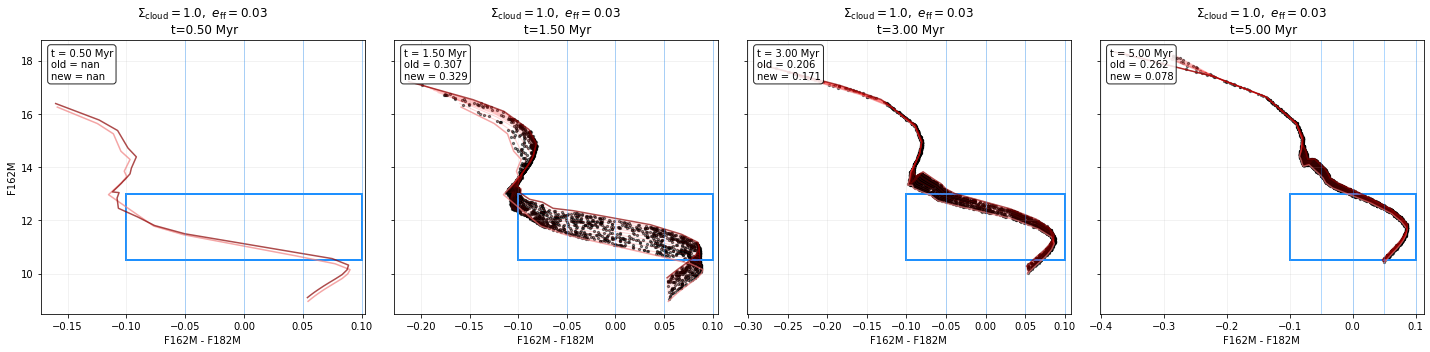

In [26]:
slow_times = [0.5, 1.5, 3.0, 5.0]
plot_cmd_evolution_with_metrics(
    SIM_PATHS['1.0_0.03'],
    slow_times,
    title_prefix=r'$\Sigma_{\rm cloud}=1.0,\ e_{\rm ff}=0.03$',
    force_single_age=False
)

In [27]:
def build_time_series(sim_path, snapshot_times_myr, instantaneous_control=False):
    rows = []

    for t in snapshot_times_myr:
        try:
            force_age = t if instantaneous_control else None
            out = evaluate_snapshot(sim_path, t, force_single_age_myr=force_age)

            rows.append({
                't_myr': t,
                'old_metric': out['old_metric']['metric'],
                'new_metric': out['new_metric']['metric'],
            })

            print(f't={t:.2f} done')

        except Exception as e:
            print(f't={t:.2f} failed: {e}')

    import pandas as pd
    return pd.DataFrame(rows)

In [28]:
slow_times = np.arange(0.2, 6.6, 0.2)
inst_times = np.arange(0.2, 2.1, 0.2)

df_slow = build_time_series(
    SIM_PATHS['1.0_0.03'],
    slow_times,
    instantaneous_control=False
)

df_inst = build_time_series(
    SIM_PATHS['1.0_1.00'],
    inst_times,
    instantaneous_control=True
)

t=0.20 failed: index 0 is out of bounds for axis 0 with size 0


/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:94: RuntimeWarning: divide by zero encountered in double_scalars
  w1 = (np.power(10, age_arr[a2]) / 1000000 - age) / (np.power(10, age_arr[a2]) / 1000000 - np.power(10, age_arr[a1]) / 1000000)
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:99: RuntimeWarning: invalid value encountered in double_scalars
  s_lum = w1 * s1[1] + w2 * s2[1]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:100: RuntimeWarning: invalid value encountered in double_scalars
  s_teff = w1 * s1[2] + w2 * s2[2]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:101: RuntimeWarning: invalid value encountered in double_scalars
  s_logg = w1 * s1[3] + w2 * s2[3]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:102: RuntimeWarning: invalid value encountered in double_scalars
  s_filt1 = w1 * s1[4] + w2 * s2[4]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:103: RuntimeWarning: invalid value encountered 

t=0.40 done


/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:94: RuntimeWarning: divide by zero encountered in double_scalars
  w1 = (np.power(10, age_arr[a2]) / 1000000 - age) / (np.power(10, age_arr[a2]) / 1000000 - np.power(10, age_arr[a1]) / 1000000)
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:99: RuntimeWarning: invalid value encountered in double_scalars
  s_lum = w1 * s1[1] + w2 * s2[1]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:100: RuntimeWarning: invalid value encountered in double_scalars
  s_teff = w1 * s1[2] + w2 * s2[2]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:101: RuntimeWarning: invalid value encountered in double_scalars
  s_logg = w1 * s1[3] + w2 * s2[3]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:102: RuntimeWarning: invalid value encountered in double_scalars
  s_filt1 = w1 * s1[4] + w2 * s2[4]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:103: RuntimeWarning: invalid value encountered 

t=0.60 done


...

t=1.60 done


/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:94: RuntimeWarning: divide by zero encountered in double_scalars
  w1 = (np.power(10, age_arr[a2]) / 1000000 - age) / (np.power(10, age_arr[a2]) / 1000000 - np.power(10, age_arr[a1]) / 1000000)
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:99: RuntimeWarning: invalid value encountered in double_scalars
  s_lum = w1 * s1[1] + w2 * s2[1]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:100: RuntimeWarning: invalid value encountered in double_scalars
  s_teff = w1 * s1[2] + w2 * s2[2]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:101: RuntimeWarning: invalid value encountered in double_scalars
  s_logg = w1 * s1[3] + w2 * s2[3]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:102: RuntimeWarning: invalid value encountered in double_scalars
  s_filt1 = w1 * s1[4] + w2 * s2[4]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:103: RuntimeWarning: invalid value encountered 

t=1.80 done


/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:94: RuntimeWarning: divide by zero encountered in double_scalars
  w1 = (np.power(10, age_arr[a2]) / 1000000 - age) / (np.power(10, age_arr[a2]) / 1000000 - np.power(10, age_arr[a1]) / 1000000)
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:99: RuntimeWarning: invalid value encountered in double_scalars
  s_lum = w1 * s1[1] + w2 * s2[1]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:100: RuntimeWarning: invalid value encountered in double_scalars
  s_teff = w1 * s1[2] + w2 * s2[2]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:101: RuntimeWarning: invalid value encountered in double_scalars
  s_logg = w1 * s1[3] + w2 * s2[3]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:102: RuntimeWarning: invalid value encountered in double_scalars
  s_filt1 = w1 * s1[4] + w2 * s2[4]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:103: RuntimeWarning: invalid value encountered 

t=2.00 done


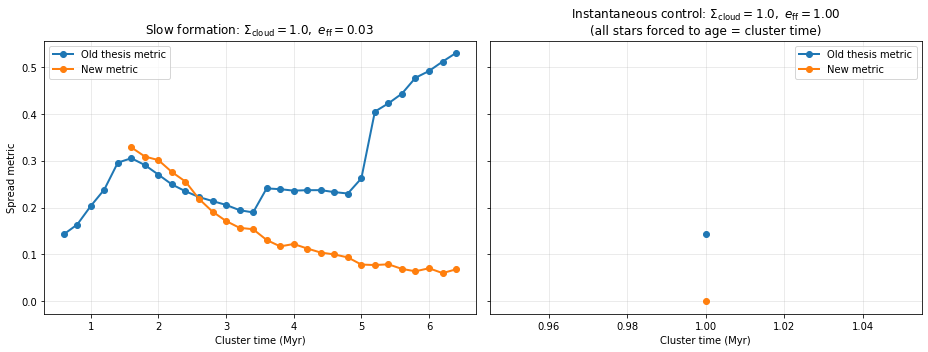

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# slow formation
ax = axes[0]
ax.plot(df_slow['t_myr'], df_slow['old_metric'], marker='o', lw=2, label='Old thesis metric')
ax.plot(df_slow['t_myr'], df_slow['new_metric'], marker='o', lw=2, label='New metric')
ax.set_title(r'Slow formation: $\Sigma_{\rm cloud}=1.0,\ e_{\rm ff}=0.03$')
ax.set_xlabel('Cluster time (Myr)')
ax.set_ylabel('Spread metric')
ax.grid(alpha=0.3)
ax.legend()

# instantaneous control
ax = axes[1]
ax.plot(df_inst['t_myr'], df_inst['old_metric'], marker='o', lw=2, label='Old thesis metric')
ax.plot(df_inst['t_myr'], df_inst['new_metric'], marker='o', lw=2, label='New metric')
ax.set_title(r'Instantaneous control: $\Sigma_{\rm cloud}=1.0,\ e_{\rm ff}=1.00$' + '\n(all stars forced to age = cluster time)')
ax.set_xlabel('Cluster time (Myr)')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

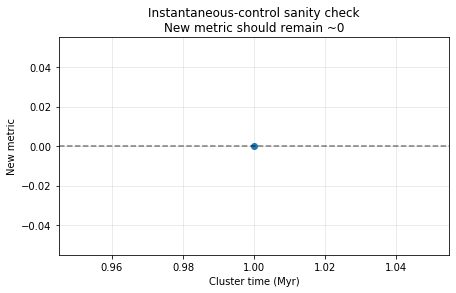

In [30]:
plt.figure(figsize=(7, 4))
plt.plot(df_inst['t_myr'], df_inst['new_metric'], marker='o')
plt.axhline(0, color='k', ls='--', alpha=0.5)
plt.xlabel('Cluster time (Myr)')
plt.ylabel('New metric')
plt.title('Instantaneous-control sanity check\nNew metric should remain ~0')
plt.grid(alpha=0.3)
plt.show()